# Propensity Score Matching
Notebook for propensity score matching analysis.

In [14]:
# ── 0. imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from causalinference import CausalModel
import warnings

warnings.filterwarnings("ignore")

df = pd.read_parquet("../data/cohort_raw.parquet")
print(f"Loaded: {df.shape[0]:,} rows")


Loaded: 10,964 rows


In [15]:
# ── 1. imputation ─────────────────────────────────────────────────────────────
# Median imputation for continuous labs before PSM
# Document which columns were imputed and at what rate — this goes in your writeup

CONTINUOUS_COVARIATES = [
    "age_at_admission",
    "icu_los_days",
    "total_fluid_ml",
    "bun",
    "creatinine",
    "bilirubin",
    "platelets",
    "wbc",
    "lactate",
    "bicarbonate",
]

CATEGORICAL_COVARIATES = ["gender", "race", "insurance"]

# report missingness before imputing
missing_report = (
    df[CONTINUOUS_COVARIATES]
    .isnull()
    .mean()
    .mul(100)
    .round(1)
    .rename("pct_missing")
    .sort_values(ascending=False)
)
print("=== Missingness before imputation ===")
print(missing_report[missing_report > 0].to_string())

# median imputation — simple and defensible for PSM covariates
imputer = SimpleImputer(strategy="median")
df_imp = df.copy()
df_imp[CONTINUOUS_COVARIATES] = imputer.fit_transform(df[CONTINUOUS_COVARIATES])

# store medians for documentation
imputation_values = dict(zip(CONTINUOUS_COVARIATES, imputer.statistics_))
print("\n=== Imputed medians ===")
for k, v in imputation_values.items():
    print(f"  {k}: {v:.2f}")

assert df_imp[CONTINUOUS_COVARIATES].isnull().sum().sum() == 0, "Imputation incomplete"
print("\n✓ No missing values in continuous covariates")


=== Missingness before imputation ===
bilirubin      53.7
lactate        35.0
wbc            26.4
platelets      26.3
bun            23.2
bicarbonate    23.2
creatinine     23.1

=== Imputed medians ===
  age_at_admission: 67.00
  icu_los_days: 2.92
  total_fluid_ml: 0.00
  bun: 28.00
  creatinine: 1.40
  bilirubin: 0.90
  platelets: 185.00
  wbc: 13.30
  lactate: 2.10
  bicarbonate: 21.00

✓ No missing values in continuous covariates


In [16]:
# ── 2. encode categoricals ────────────────────────────────────────────────────

df_enc = pd.get_dummies(
    df_imp,
    columns=CATEGORICAL_COVARIATES,
    drop_first=True,  # avoid dummy variable trap
    dtype=float,
)

# collect the full feature list after encoding
encoded_cats = [
    c
    for c in df_enc.columns
    if any(c.startswith(cat + "_") for cat in CATEGORICAL_COVARIATES)
]

ALL_FEATURES = CONTINUOUS_COVARIATES + encoded_cats

print(f"Feature matrix: {len(ALL_FEATURES)} covariates")
print(ALL_FEATURES)


Feature matrix: 46 covariates
['age_at_admission', 'icu_los_days', 'total_fluid_ml', 'bun', 'creatinine', 'bilirubin', 'platelets', 'wbc', 'lactate', 'bicarbonate', 'gender_M', 'race_ASIAN', 'race_ASIAN - ASIAN INDIAN', 'race_ASIAN - CHINESE', 'race_ASIAN - KOREAN', 'race_ASIAN - SOUTH EAST ASIAN', 'race_BLACK/AFRICAN', 'race_BLACK/AFRICAN AMERICAN', 'race_BLACK/CAPE VERDEAN', 'race_BLACK/CARIBBEAN ISLAND', 'race_HISPANIC OR LATINO', 'race_HISPANIC/LATINO - CENTRAL AMERICAN', 'race_HISPANIC/LATINO - COLUMBIAN', 'race_HISPANIC/LATINO - CUBAN', 'race_HISPANIC/LATINO - DOMINICAN', 'race_HISPANIC/LATINO - GUATEMALAN', 'race_HISPANIC/LATINO - HONDURAN', 'race_HISPANIC/LATINO - MEXICAN', 'race_HISPANIC/LATINO - PUERTO RICAN', 'race_HISPANIC/LATINO - SALVADORAN', 'race_MULTIPLE RACE/ETHNICITY', 'race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER', 'race_OTHER', 'race_PATIENT DECLINED TO ANSWER', 'race_PORTUGUESE', 'race_SOUTH AMERICAN', 'race_UNABLE TO OBTAIN', 'race_UNKNOWN', 'race_WHITE', 'race

In [17]:
# ── 3. fit propensity score model ─────────────────────────────────────────────
# Logistic regression is standard for PSM in clinical RWE
# Scale features first — important for logistic regression convergence

X = df_enc[ALL_FEATURES].values
y = df_enc["treatment_group"].values

pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "lr",
            LogisticRegression(
                max_iter=1000,
                C=1.0,  # default regularization
                solver="lbfgs",
                random_state=42,
            ),
        ),
    ]
)

pipe.fit(X, y)

# propensity score = P(treatment=1 | covariates)
df_enc["propensity_score"] = pipe.predict_proba(X)[:, 1]

print("=== Propensity score summary ===")
print(
    df_enc.groupby("treatment_label")["propensity_score"]
    .describe()
    .round(3)
    .to_string()
)


=== Propensity score summary ===
                  count   mean    std    min    25%    50%    75%    max
treatment_label                                                         
fluid_only       4941.0  0.495  0.127  0.110  0.413  0.475  0.558  0.991
vasopressor      6023.0  0.594  0.161  0.156  0.475  0.570  0.700  0.998


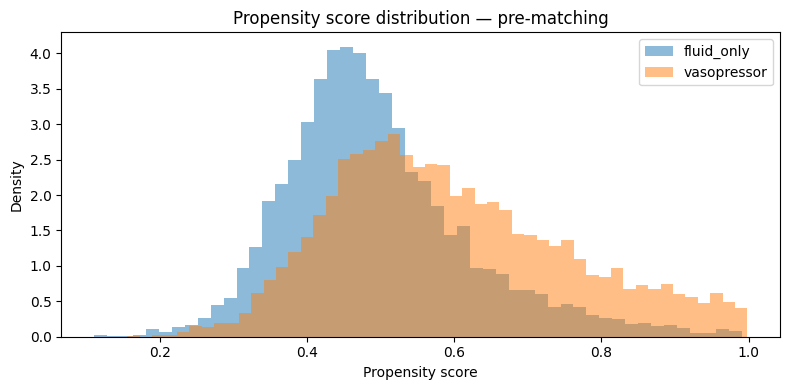


Common support: [0.156, 0.991]
Trimmed 22 patients outside common support
Remaining: 10,942


In [18]:
# ── 4. check common support (overlap) ─────────────────────────────────────────
# Patients outside the region of common support can't be matched
# and should be trimmed — document how many you trim

fig, ax = plt.subplots(figsize=(8, 4))

for label, grp in df_enc.groupby("treatment_label"):
    ax.hist(grp["propensity_score"], bins=50, alpha=0.5, density=True, label=label)

ax.set_xlabel("Propensity score")
ax.set_ylabel("Density")
ax.set_title("Propensity score distribution — pre-matching")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/02_ps_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# trim to common support: drop patients outside [min_treated, max_control] overlap
ps_treated_min = df_enc.loc[df_enc["treatment_group"] == 1, "propensity_score"].min()
ps_treated_max = df_enc.loc[df_enc["treatment_group"] == 1, "propensity_score"].max()
ps_control_min = df_enc.loc[df_enc["treatment_group"] == 0, "propensity_score"].min()
ps_control_max = df_enc.loc[df_enc["treatment_group"] == 0, "propensity_score"].max()

ps_low = max(ps_treated_min, ps_control_min)
ps_high = min(ps_treated_max, ps_control_max)

n_before = len(df_enc)
df_trimmed = df_enc[df_enc["propensity_score"].between(ps_low, ps_high)].copy()
n_after = len(df_trimmed)

print(f"\nCommon support: [{ps_low:.3f}, {ps_high:.3f}]")
print(f"Trimmed {n_before - n_after:,} patients outside common support")
print(f"Remaining: {n_after:,}")


In [19]:
# ── 5. 1:1 nearest neighbor matching without replacement ──────────────────────
# Manual implementation — gives you full control and transparency
# Caliper = 0.2 * SD of logit(propensity score), which is the standard rule

logit_ps = np.log(df_trimmed["propensity_score"] / (1 - df_trimmed["propensity_score"]))
caliper = 0.2 * logit_ps.std()
print(f"Caliper (0.2 × SD of logit PS): {caliper:.4f}")

treated = df_trimmed[df_trimmed["treatment_group"] == 1].copy()
controls = df_trimmed[df_trimmed["treatment_group"] == 0].copy()

treated["logit_ps"] = logit_ps[treated.index]
controls["logit_ps"] = logit_ps[controls.index]

# greedy nearest-neighbor match
matched_treated_idx = []
matched_control_idx = []
used_controls = set()

treated_sorted = treated.sort_values("propensity_score")

for idx, row in treated_sorted.iterrows():
    available = controls[~controls.index.isin(used_controls)].copy()
    if available.empty:
        break

    diff = (available["logit_ps"] - row["logit_ps"]).abs()
    best_idx = diff.idxmin()
    best_diff = diff.min()

    if best_diff <= caliper:
        matched_treated_idx.append(idx)
        matched_control_idx.append(best_idx)
        used_controls.add(best_idx)

print(f"\nMatched pairs: {len(matched_treated_idx):,}")
print(
    f"Unmatched treated (outside caliper): {len(treated) - len(matched_treated_idx):,}"
)

matched_df = pd.concat(
    [df_trimmed.loc[matched_treated_idx], df_trimmed.loc[matched_control_idx]]
).copy()

matched_df["match_id"] = list(range(len(matched_treated_idx))) + list(
    range(len(matched_control_idx))
)

print(f"\nMatched cohort size: {len(matched_df):,} patients")
print(matched_df["treatment_label"].value_counts())


Caliper (0.2 × SD of logit PS): 0.1568

Matched pairs: 3,916
Unmatched treated (outside caliper): 2,089

Matched cohort size: 7,832 patients
treatment_label
vasopressor    3916
fluid_only     3916
Name: count, dtype: Int64


In [20]:
# ── 6. post-match balance assessment ─────────────────────────────────────────
# This is the key diagnostic — SMD should drop below 0.1 for all covariates
# If it doesn't, you need to revisit your PS model (add interactions, splines)


def compute_smd(df, col, treatment_col="treatment_group"):
    g1 = df.loc[df[treatment_col] == 1, col].dropna()
    g0 = df.loc[df[treatment_col] == 0, col].dropna()
    pooled_sd = np.sqrt((g1.std() ** 2 + g0.std() ** 2) / 2)
    if pooled_sd == 0:
        return np.nan
    return abs((g1.mean() - g0.mean()) / pooled_sd)


smd_rows = []
for col in CONTINUOUS_COVARIATES:
    smd_rows.append(
        {
            "covariate": col,
            "smd_before": compute_smd(df_enc, col),
            "smd_after": compute_smd(matched_df, col),
            "mean_treated_before": df_enc.loc[df_enc["treatment_group"] == 1, col]
            .mean()
            .round(2),
            "mean_control_before": df_enc.loc[df_enc["treatment_group"] == 0, col]
            .mean()
            .round(2),
            "mean_treated_after": matched_df.loc[
                matched_df["treatment_group"] == 1, col
            ]
            .mean()
            .round(2),
            "mean_control_after": matched_df.loc[
                matched_df["treatment_group"] == 0, col
            ]
            .mean()
            .round(2),
        }
    )

balance_df = pd.DataFrame(smd_rows).sort_values("smd_before", ascending=False)

print("=== Balance table: before vs after matching ===")
print(
    balance_df[
        [
            "covariate",
            "mean_treated_before",
            "mean_control_before",
            "smd_before",
            "mean_treated_after",
            "mean_control_after",
            "smd_after",
        ]
    ]
    .round(3)
    .to_string(index=False)
)

n_imbalanced_after = (balance_df["smd_after"] > 0.1).sum()
print(f"\nCovariates still imbalanced (SMD > 0.1) after matching: {n_imbalanced_after}")

if n_imbalanced_after > 0:
    print("⚠ Consider adding interaction terms or splines to PS model")
else:
    print("✓ All covariates balanced")


=== Balance table: before vs after matching ===
       covariate  mean_treated_before  mean_control_before  smd_before  mean_treated_after  mean_control_after  smd_after
         lactate                 3.07                 2.20       0.405                2.23                2.29      0.043
     bicarbonate                20.01                21.69       0.372               21.43               21.22      0.050
    icu_los_days                 6.91                 4.58       0.300                5.19                5.15      0.005
      creatinine                 1.99                 1.63       0.228                1.66                1.73      0.046
             bun                36.39                31.93       0.184               32.46               33.55      0.048
             wbc                15.45                13.80       0.159               14.09               14.26      0.018
age_at_admission                66.29                64.86       0.095               65.74        

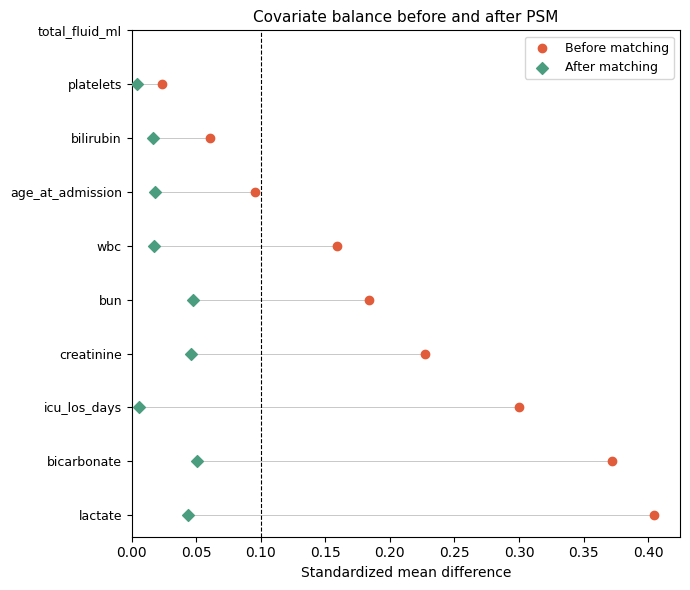

In [21]:
# ── 7. love plot — before and after ──────────────────────────────────────────
# The standard visualization for PSM balance in RWE papers

fig, ax = plt.subplots(figsize=(7, 6))

y_pos = range(len(balance_df))

ax.scatter(
    balance_df["smd_before"],
    y_pos,
    marker="o",
    color="#e05c3a",
    label="Before matching",
    zorder=3,
)
ax.scatter(
    balance_df["smd_after"],
    y_pos,
    marker="D",
    color="#4a9e7f",
    label="After matching",
    zorder=3,
)

for i, row in enumerate(balance_df.itertuples()):
    ax.plot(
        [row.smd_before, row.smd_after], [i, i], color="gray", linewidth=0.6, alpha=0.5
    )

ax.axvline(0.1, color="black", linestyle="--", linewidth=0.8)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(balance_df["covariate"], fontsize=9)
ax.set_xlabel("Standardized mean difference")
ax.set_title("Covariate balance before and after PSM", fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig("../figures/02_love_plot_postmatch.png", dpi=150, bbox_inches="tight")
plt.show()


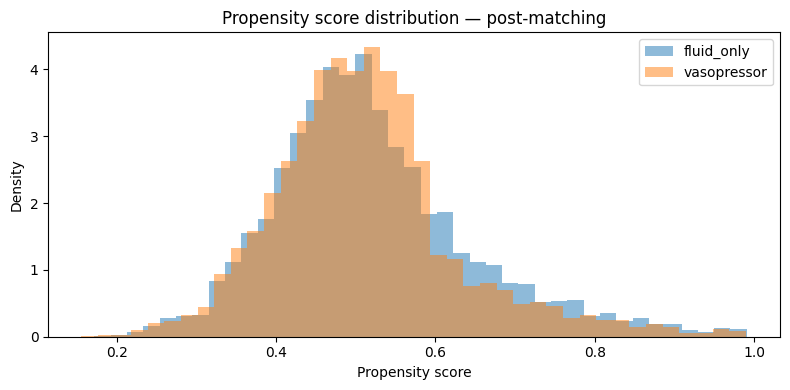

In [22]:
# ── 8. post-match propensity score overlap ────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))

for label, grp in matched_df.groupby("treatment_label"):
    ax.hist(grp["propensity_score"], bins=40, alpha=0.5, density=True, label=label)

ax.set_xlabel("Propensity score")
ax.set_ylabel("Density")
ax.set_title("Propensity score distribution — post-matching")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/02_ps_overlap_postmatch.png", dpi=150, bbox_inches="tight")
plt.show()


In [23]:
# ── 9. save matched cohort ────────────────────────────────────────────────────

matched_df.to_parquet("../data/cohort_matched.parquet", index=False)
print(
    f"Saved cohort_matched.parquet — {len(matched_df):,} rows "
    f"({len(matched_treated_idx):,} matched pairs)"
)

print("\n=== Notebook 02 complete ===")
print("Next step: 03_survival.ipynb — KM curves + Cox PH on matched cohort")


Saved cohort_matched.parquet — 7,832 rows (3,916 matched pairs)

=== Notebook 02 complete ===
Next step: 03_survival.ipynb — KM curves + Cox PH on matched cohort
